## LING 498 Hackathon - Phoneme token frequencies (CMUdict)

**Question: Do ARPAbet phoneme tokens show Zipf-like rank-frequency patterns?**

In [20]:
import re
from nltk.corpus import cmudict
from nltk import FreqDist

# If CMUdict isn't already downloaded in runtime, uncomment:
# nltk.download("cmudict")

In [21]:
# Helpter functions
def zipf_prep(items, min_count=1):
    fd = FreqDist(items)
    # drop ultra-rare if desired
    items2 = [(k,v) for k,v in fd.items() if v >= min_count]
    items2.sort(key=lambda kv: kv[1], reverse=True)
    return items2  # list of (item, count) sorted

def zipf_quick_report(items, title="", topn=15):
    ranked = zipf_prep(items)
    print(f"\n=== {title} ===")
    print(f"Types: {len(ranked)} | Tokens: {sum(c for _,c in ranked)}")
    print("Top items:")
    for i,(k,v) in enumerate(ranked[:topn], start=1):
        print(f"{i:>2}. {str(k)[:40]:<40} {v}")
    # simple “Zipf-ness” sanity check (no regression): f1 ~ 2*f2 ~ 3*f3?
    if len(ranked) >= 5:
        f1,f2,f3,f4,f5 = [ranked[i][1] for i in range(5)]
        print("\nHeuristic ratios (closer to 1 is more Zipf-like):")
        print(" f1/(2*f2) =", round(f1/(2*f2), 3))
        print(" f1/(3*f3) =", round(f1/(3*f3), 3))
        print(" f1/(4*f4) =", round(f1/(4*f4), 3))
        print(" f1/(5*f5) =", round(f1/(5*f5), 3))
    return ranked

# Optional plotting cell (instructor can pre-enable if matplotlib is available)
def zipf_plot(ranked, n=1000, title="Top 1000 _______"):
    import matplotlib.pyplot as plt
    ranks = list(range(1, min(n, len(ranked)) + 1))
    freqs = [ranked[i - 1][1] for i in ranks]
    plt.figure(figsize=(6, 4))
    plt.loglog(ranks, freqs, marker='.')
    plt.xlabel("rank (log)")
    plt.ylabel("frequency (log)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [22]:
# Load CMUdict entries: (word, pronunciation_list)
entries = cmudict.entries()
print("Number of entries:", len(entries))

Number of entries: 133737


In [23]:
# Remove stress digits from phones (AH0 -> AH)
def normalize_phone(phone: str) -> str:
    return re.sub(r"\d", "", phone)

In [24]:
# List of phoneme tokens across the lexicon
phones = []
for word, pron in entries:
    phones.extend(normalize_phone(p) for p in pron)


=== CMUdict phoneme token frequencies (stress stripped) ===
Types: 39 | Tokens: 853918
Top items:
 1. AH                                       71410
 2. N                                        60564
 3. S                                        50427
 4. IH                                       50093
 5. L                                        49479
 6. T                                        48549
 7. R                                        46046
 8. K                                        42502
 9. IY                                       34504
10. D                                        32389
11. M                                        29347
12. ER                                       29027
13. Z                                        27842
14. EH                                       27398
15. AA                                       24546

Heuristic ratios (closer to 1 is more Zipf-like):
 f1/(2*f2) = 0.59
 f1/(3*f3) = 0.472
 f1/(4*f4) = 0.356
 f1/(5*f5) = 0.289


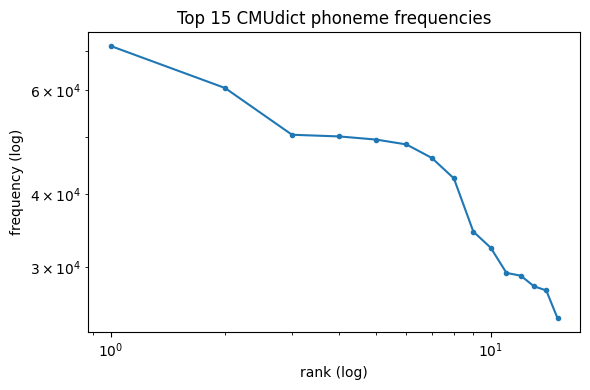

In [ ]:
# Count, rank & print Zipf-style report
ranked = zipf_quick_report(phones, title="CMUdict phoneme token frequencies (stress stripped)")
zipf_plot(
    ranked,
    n=15,
    title="Top 15 CMUdict phoneme frequencies"
)